In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from warnings import filterwarnings
filterwarnings('ignore')

In [29]:
data = pd.read_csv('WB_FSI.csv')
data.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,SEX,...,DATA_SOURCE_LABEL,UNIT_TYPE,UNIT_TYPE_LABEL,TIME_FORMAT,TIME_FORMAT_LABEL,COMMENT_OBS,OBS_STATUS,OBS_STATUS_LABEL,OBS_CONF,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ABW,Aruba,WB_FSI_BM_KLT_DINV_CD_WD,"Foreign direct investment, net outflows (BoP, ...",_T,...,NaN,CUR,Currency,602,CCYY,NaN,O,Missing value,PU,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AFE,Africa Eastern and Southern,WB_FSI_BM_KLT_DINV_CD_WD,"Foreign direct investment, net outflows (BoP, ...",_T,...,NaN,CUR,Currency,602,CCYY,NaN,O,Missing value,PU,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AFG,Afghanistan,WB_FSI_BM_KLT_DINV_CD_WD,"Foreign direct investment, net outflows (BoP, ...",_T,...,NaN,CUR,Currency,602,CCYY,NaN,O,Missing value,PU,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AFW,Africa Western and Central,WB_FSI_BM_KLT_DINV_CD_WD,"Foreign direct investment, net outflows (BoP, ...",_T,...,NaN,CUR,Currency,602,CCYY,NaN,O,Missing value,PU,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AGO,Angola,WB_FSI_BM_KLT_DINV_CD_WD,"Foreign direct investment, net outflows (BoP, ...",_T,...,NaN,CUR,Currency,602,CCYY,NaN,O,Missing value,PU,Public


In [30]:
data.shape

(1055488, 43)

In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1055488 entries, 0 to 1055487
Data columns (total 43 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   STRUCTURE               1055488 non-null  object 
 1   STRUCTURE_ID            1055488 non-null  object 
 2   ACTION                  1055488 non-null  object 
 3   FREQ                    1055488 non-null  object 
 4   FREQ_LABEL              1055488 non-null  object 
 5   REF_AREA                1055488 non-null  object 
 6   REF_AREA_LABEL          1055488 non-null  object 
 7   INDICATOR               1055488 non-null  object 
 8   INDICATOR_LABEL         1055488 non-null  object 
 9   SEX                     1055488 non-null  object 
 10  SEX_LABEL               1055488 non-null  object 
 11  AGE                     1055488 non-null  object 
 12  AGE_LABEL               1055488 non-null  object 
 13  URBANISATION            1055488 non-null  object 
 14  UR

In [32]:
data['REF_AREA_LABEL'].unique()

array(['Aruba', 'Africa Eastern and Southern', 'Afghanistan',
       'Africa Western and Central', 'Angola', 'Albania', 'Andorra',
       'Arab World', 'United Arab Emirates', 'Argentina', 'Armenia',
       'American Samoa', 'Antigua and Barbuda', 'Australia', 'Austria',
       'Azerbaijan', 'Burundi', 'Belgium', 'Benin', 'Burkina Faso',
       'Bangladesh', 'Bulgaria', 'Bahrain', 'Bahamas, The',
       'Bosnia and Herzegovina', 'Belarus', 'Belize', 'Bermuda',
       'Bolivia', 'Brazil', 'Barbados', 'Brunei Darussalam', 'Bhutan',
       'Botswana', 'Central African Republic', 'Canada',
       'Central Electricity Board (CEB)', 'Switzerland',
       'Channel Islands', 'Chile', 'China', "Cote d'Ivoire", 'Cameroon',
       'Congo, Dem. Rep.', 'Congo, Rep.', 'Colombia', 'Comoros',
       'Cabo Verde', 'Costa Rica', 'Caribbean small states', 'Cuba',
       'Curacao', 'Cayman Islands', 'Cyprus', 'Czechia', 'Germany',
       'Djibouti', 'Dominica', 'Denmark', 'Dominican Republic', 'Algeria',


In [33]:
data['INDICATOR_LABEL'].unique()

array(['Foreign direct investment, net outflows (BoP, current US$)',
       'Foreign direct investment, net outflows (% of GDP)',
       'Personal remittances, paid (current US$)',
       'Foreign direct investment, net (BoP, current US$)',
       'Portfolio Investment, net (BoP, current US$)',
       'Foreign direct investment, net inflows (BoP, current US$)',
       'Portfolio equity, net inflows (BoP, current US$)',
       'Personal transfers, receipts (BoP, current US$)',
       'Personal remittances, received (% of GDP)',
       'S&P Global Equity Indices (annual % change)',
       'Market capitalization of listed domestic companies (current US$)',
       'Market capitalization of listed domestic companies (% of GDP)',
       'Listed domestic companies, total',
       'Stocks traded, total value (current US$)',
       'Stocks traded, total value (% of GDP)',
       'Stocks traded, turnover ratio of domestic shares (%)',
       'Portfolio investment, bonds (PPG + PNG) (NFL, current

In [34]:
data['INDICATOR_LABEL'].nunique()

62

***Saving the all the unique indicators.***

In [35]:
unique_indicators = data[['INDICATOR', 'INDICATOR_LABEL']].drop_duplicates()
unique_indicators.reset_index(drop=True)
unique_indicators.head()

unique_indicators.to_csv('Unique_Indicators.csv', index=False)

***Pivoting the dataset so that each indicator label becomes a separate column for easier data handling.***

In [36]:
data = data.pivot(
    index=['REF_AREA','REF_AREA_LABEL','TIME_PERIOD'],
    columns='INDICATOR_LABEL',
    values='OBS_VALUE'
).reset_index()

In [37]:
data.shape

(17024, 65)

In [38]:
data.columns

Index(['REF_AREA', 'REF_AREA_LABEL', 'TIME_PERIOD',
       'Automated teller machines (ATMs) (per 100,000 adults)',
       'Average transaction cost of sending remittances from a specific country (%)',
       'Average transaction cost of sending remittances to a specific country (%)',
       'Bank capital to assets ratio (%)',
       'Bank liquid reserves to bank assets ratio (%)',
       'Bank nonperforming loans to total gross loans (%)',
       'Borrowers from commercial banks (per 1,000 adults)',
       'Broad money (% of GDP)', 'Broad money (current LCU)',
       'Broad money growth (annual %)', 'Broad money to total reserves ratio',
       'Claims on central government (annual growth as % of broad money)',
       'Claims on central government, etc. (% GDP)',
       'Claims on other sectors of the domestic economy (% of GDP)',
       'Claims on other sectors of the domestic economy (annual growth as % of broad money)',
       'Claims on private sector (annual growth as % of broad 

In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17024 entries, 0 to 17023
Data columns (total 65 columns):
 #   Column                                                                               Non-Null Count  Dtype  
---  ------                                                                               --------------  -----  
 0   REF_AREA                                                                             17024 non-null  object 
 1   REF_AREA_LABEL                                                                       17024 non-null  object 
 2   TIME_PERIOD                                                                          17024 non-null  int64  
 3   Automated teller machines (ATMs) (per 100,000 adults)                                3794 non-null   float64
 4   Average transaction cost of sending remittances from a specific country (%)          353 non-null    float64
 5   Average transaction cost of sending remittances to a specific country (%)            780

In [40]:
data.head()

INDICATOR_LABEL,REF_AREA,REF_AREA_LABEL,TIME_PERIOD,"Automated teller machines (ATMs) (per 100,000 adults)",Average transaction cost of sending remittances from a specific country (%),Average transaction cost of sending remittances to a specific country (%),Bank capital to assets ratio (%),Bank liquid reserves to bank assets ratio (%),Bank nonperforming loans to total gross loans (%),"Borrowers from commercial banks (per 1,000 adults)",...,Real effective exchange rate index (2010 = 100),Real interest rate (%),"Risk premium on lending (lending rate minus treasury bill rate, %)",S&P Global Equity Indices (annual % change),"Stocks traded, total value (% of GDP)","Stocks traded, total value (current US$)","Stocks traded, turnover ratio of domestic shares (%)",Strength of legal rights index (0=weak to 12=strong),Total reserves minus gold (current US$),Wholesale price index (2010 = 100)
0,ABW,Aruba,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,Aruba,1961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,Aruba,1962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABW,Aruba,1963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,Aruba,1964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


***G20 Countries***

In [41]:
countries = ["ARG", "AUS", "BRA", "CAN", "CHN", "FRA", "DEU", "IND", "IDN", "ITA",
            "JPN", "MEX", "RUS", "SAU", "ZAF", "KOR", "TUR", "GBR", "USA", "EUU"]

G20_data = data[(data['REF_AREA'].isin(countries))].reset_index(drop=True)

In [42]:
G20_data['REF_AREA_LABEL'].unique()

array(['Argentina', 'Australia', 'Brazil', 'Canada', 'China', 'Germany',
       'European Union', 'France', 'United Kingdom', 'Indonesia', 'India',
       'Italy', 'Japan', 'Korea, Rep.', 'Mexico', 'Russian Federation',
       'Saudi Arabia', 'Turkiye', 'United States', 'South Africa'],
      dtype=object)

***Looking for the indicators that don't have fully missing value for G20 countries.***

In [43]:
indicators = G20_data.columns.difference(['REF_AREA','REF_AREA_LABEL','INDICATOR','TIME_PERIOD'])
fully_missing = G20_data.groupby('REF_AREA')[indicators].apply(lambda x: x.isnull().all())

# Keep only indicators that are not fully missing (i.e., all False across countries)
valid_indicators = fully_missing.columns[(fully_missing == False).all()]

print("Indicators available for all countries:")
print('-'*40)
print(valid_indicators)

Indicators available for all countries:
----------------------------------------
Index(['Automated teller machines (ATMs) (per 100,000 adults)',
       'Claims on central government, etc. (% GDP)',
       'Commercial bank branches (per 100,000 adults)',
       'Depth of credit information index (0=low to 8=high)',
       'Domestic credit to private sector (% of GDP)',
       'Domestic credit to private sector by banks (% of GDP)',
       'Foreign direct investment, net inflows (BoP, current US$)',
       'Foreign direct investment, net outflows (% of GDP)',
       'Foreign direct investment, net outflows (BoP, current US$)',
       'International migrant stock (% of population)',
       'International migrant stock, total',
       'Listed domestic companies, total',
       'Market capitalization of listed domestic companies (% of GDP)',
       'Market capitalization of listed domestic companies (current US$)',
       'Monetary Sector credit to private sector (% GDP)', 'Net migration',


***Economically meaningful indicators that drive financial behavior***

In [45]:
selected_indicators = [
    'Domestic credit to private sector (% of GDP)',
    'Domestic credit to private sector by banks (% of GDP)',
    'Monetary Sector credit to private sector (% GDP)',
    'Market capitalization of listed domestic companies (% of GDP)',
    'Stocks traded, total value (% of GDP)',
    'Stocks traded, turnover ratio of domestic shares (%)',
    'Foreign direct investment, net inflows (BoP, current US$)',
    'Foreign direct investment, net outflows (% of GDP)',
    'Portfolio equity, net inflows (BoP, current US$)',
    'Private credit bureau coverage (% of adults)',
    'Public credit registry coverage (% of adults)',
    'Depth of credit information index (0=low to 8=high)',
    'Strength of legal rights index (0=weak to 12=strong)'
]

df = G20_data[['REF_AREA', 'REF_AREA_LABEL', 'TIME_PERIOD'] + selected_indicators]
df.head()

INDICATOR_LABEL,REF_AREA,REF_AREA_LABEL,TIME_PERIOD,Domestic credit to private sector (% of GDP),Domestic credit to private sector by banks (% of GDP),Monetary Sector credit to private sector (% GDP),Market capitalization of listed domestic companies (% of GDP),"Stocks traded, total value (% of GDP)","Stocks traded, turnover ratio of domestic shares (%)","Foreign direct investment, net inflows (BoP, current US$)","Foreign direct investment, net outflows (% of GDP)","Portfolio equity, net inflows (BoP, current US$)",Private credit bureau coverage (% of adults),Public credit registry coverage (% of adults),Depth of credit information index (0=low to 8=high),Strength of legal rights index (0=weak to 12=strong)
0,ARG,Argentina,1960,10.797747,10.797747,10.797747,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ARG,Argentina,1961,11.810043,11.810043,11.810043,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ARG,Argentina,1962,10.228215,10.228215,10.228215,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ARG,Argentina,1963,9.902517,9.902517,9.902517,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ARG,Argentina,1964,9.402677,9.402677,9.402677,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
df.columns

Index(['REF_AREA', 'REF_AREA_LABEL', 'TIME_PERIOD',
       'Domestic credit to private sector (% of GDP)',
       'Domestic credit to private sector by banks (% of GDP)',
       'Monetary Sector credit to private sector (% GDP)',
       'Market capitalization of listed domestic companies (% of GDP)',
       'Stocks traded, total value (% of GDP)',
       'Stocks traded, turnover ratio of domestic shares (%)',
       'Foreign direct investment, net inflows (BoP, current US$)',
       'Foreign direct investment, net outflows (% of GDP)',
       'Portfolio equity, net inflows (BoP, current US$)',
       'Private credit bureau coverage (% of adults)',
       'Public credit registry coverage (% of adults)',
       'Depth of credit information index (0=low to 8=high)',
       'Strength of legal rights index (0=weak to 12=strong)'],
      dtype='object', name='INDICATOR_LABEL')

In [47]:
df.shape

(1280, 16)

***Missing Percentage of Indicators for each Country***

In [53]:
missing_per = df.groupby('REF_AREA_LABEL')[selected_indicators].apply(lambda x: x.isnull().mean()* 100)
missing_per = missing_per.reset_index(drop=True)
missing_per.sort_values(selected_indicators, ignore_index=True)

INDICATOR_LABEL,Domestic credit to private sector (% of GDP),Domestic credit to private sector by banks (% of GDP),Monetary Sector credit to private sector (% GDP),Market capitalization of listed domestic companies (% of GDP),"Stocks traded, total value (% of GDP)","Stocks traded, turnover ratio of domestic shares (%)","Foreign direct investment, net inflows (BoP, current US$)","Foreign direct investment, net outflows (% of GDP)","Portfolio equity, net inflows (BoP, current US$)",Private credit bureau coverage (% of adults),Public credit registry coverage (% of adults),Depth of credit information index (0=low to 8=high),Strength of legal rights index (0=weak to 12=strong)
0,0.0000,0.0000,0.0000,25.0000,25.0000,46.8750,17.1875,17.1875,15.6250,89.0625,89.0625,89.0625,89.0625
1,0.0000,0.0000,0.0000,31.2500,25.0000,31.2500,17.1875,17.1875,0.0000,75.0000,75.0000,89.0625,89.0625
2,0.0000,0.0000,0.0000,31.2500,31.2500,31.2500,17.1875,18.7500,25.0000,75.0000,75.0000,89.0625,89.0625
3,0.0000,0.0000,0.0000,34.3750,32.8125,34.3750,17.1875,17.1875,15.6250,75.0000,75.0000,89.0625,89.0625
4,0.0000,0.0000,0.0000,37.5000,37.5000,28.1250,17.1875,37.5000,25.0000,75.0000,75.0000,89.0625,89.0625
5,3.1250,0.0000,3.1250,64.0625,46.8750,64.0625,17.1875,46.8750,23.4375,89.0625,89.0625,89.0625,89.0625
6,3.1250,3.1250,3.1250,64.0625,64.0625,64.0625,17.1875,25.0000,23.4375,89.0625,89.0625,89.0625,89.0625
7,9.3750,9.3750,9.3750,78.1250,65.6250,78.1250,17.1875,18.7500,37.5000,75.0000,75.0000,89.0625,89.0625
8,10.9375,9.3750,9.3750,25.0000,25.0000,25.0000,17.1875,17.1875,0.0000,75.0000,75.0000,89.0625,89.0625
9,15.6250,0.0000,0.0000,25.0000,25.0000,25.0000,17.1875,17.1875,26.5625,89.0625,89.0625,89.0625,89.0625


***Removing the indicators with missing values > 50 for all countries***

In [54]:
remove_indicators = missing_per.columns[(missing_per > 50).all()]

print("Indicators missing >50% for all countries:")
print(list(remove_indicators))

Indicators missing >50% for all countries:
['Private credit bureau coverage (% of adults)', 'Public credit registry coverage (% of adults)', 'Depth of credit information index (0=low to 8=high)', 'Strength of legal rights index (0=weak to 12=strong)']


In [56]:
df = df.drop(columns=remove_indicators, axis=1)
print('-'*40)
print(df.shape)
print('-'*40)
print(df.columns)

----------------------------------------
(1280, 12)
----------------------------------------
Index(['REF_AREA', 'REF_AREA_LABEL', 'TIME_PERIOD',
       'Domestic credit to private sector (% of GDP)',
       'Domestic credit to private sector by banks (% of GDP)',
       'Monetary Sector credit to private sector (% GDP)',
       'Market capitalization of listed domestic companies (% of GDP)',
       'Stocks traded, total value (% of GDP)',
       'Stocks traded, turnover ratio of domestic shares (%)',
       'Foreign direct investment, net inflows (BoP, current US$)',
       'Foreign direct investment, net outflows (% of GDP)',
       'Portfolio equity, net inflows (BoP, current US$)'],
      dtype='object', name='INDICATOR_LABEL')


***Imputing missing values***

In [58]:
indicator_cols = df.columns.difference(['REF_AREA','REF_AREA_LABEL','TIME_PERIOD'])
df[indicator_cols] = df.groupby('REF_AREA_LABEL')[indicator_cols].transform(
    lambda x: x.interpolate(method='linear').ffill().bfill()
).reset_index(drop=True)

In [60]:
df.isnull().sum().sum()

0

In [57]:
df.groupby('REF_AREA_LABEL')['TIME_PERIOD'].agg(['min','max','count'])

,min,max,count
REF_AREA_LABEL,,,
Argentina,1960,2023,64
Australia,1960,2023,64
Brazil,1960,2023,64
Canada,1960,2023,64
China,1960,2023,64
European Union,1960,2023,64
France,1960,2023,64
Germany,1960,2023,64
India,1960,2023,64


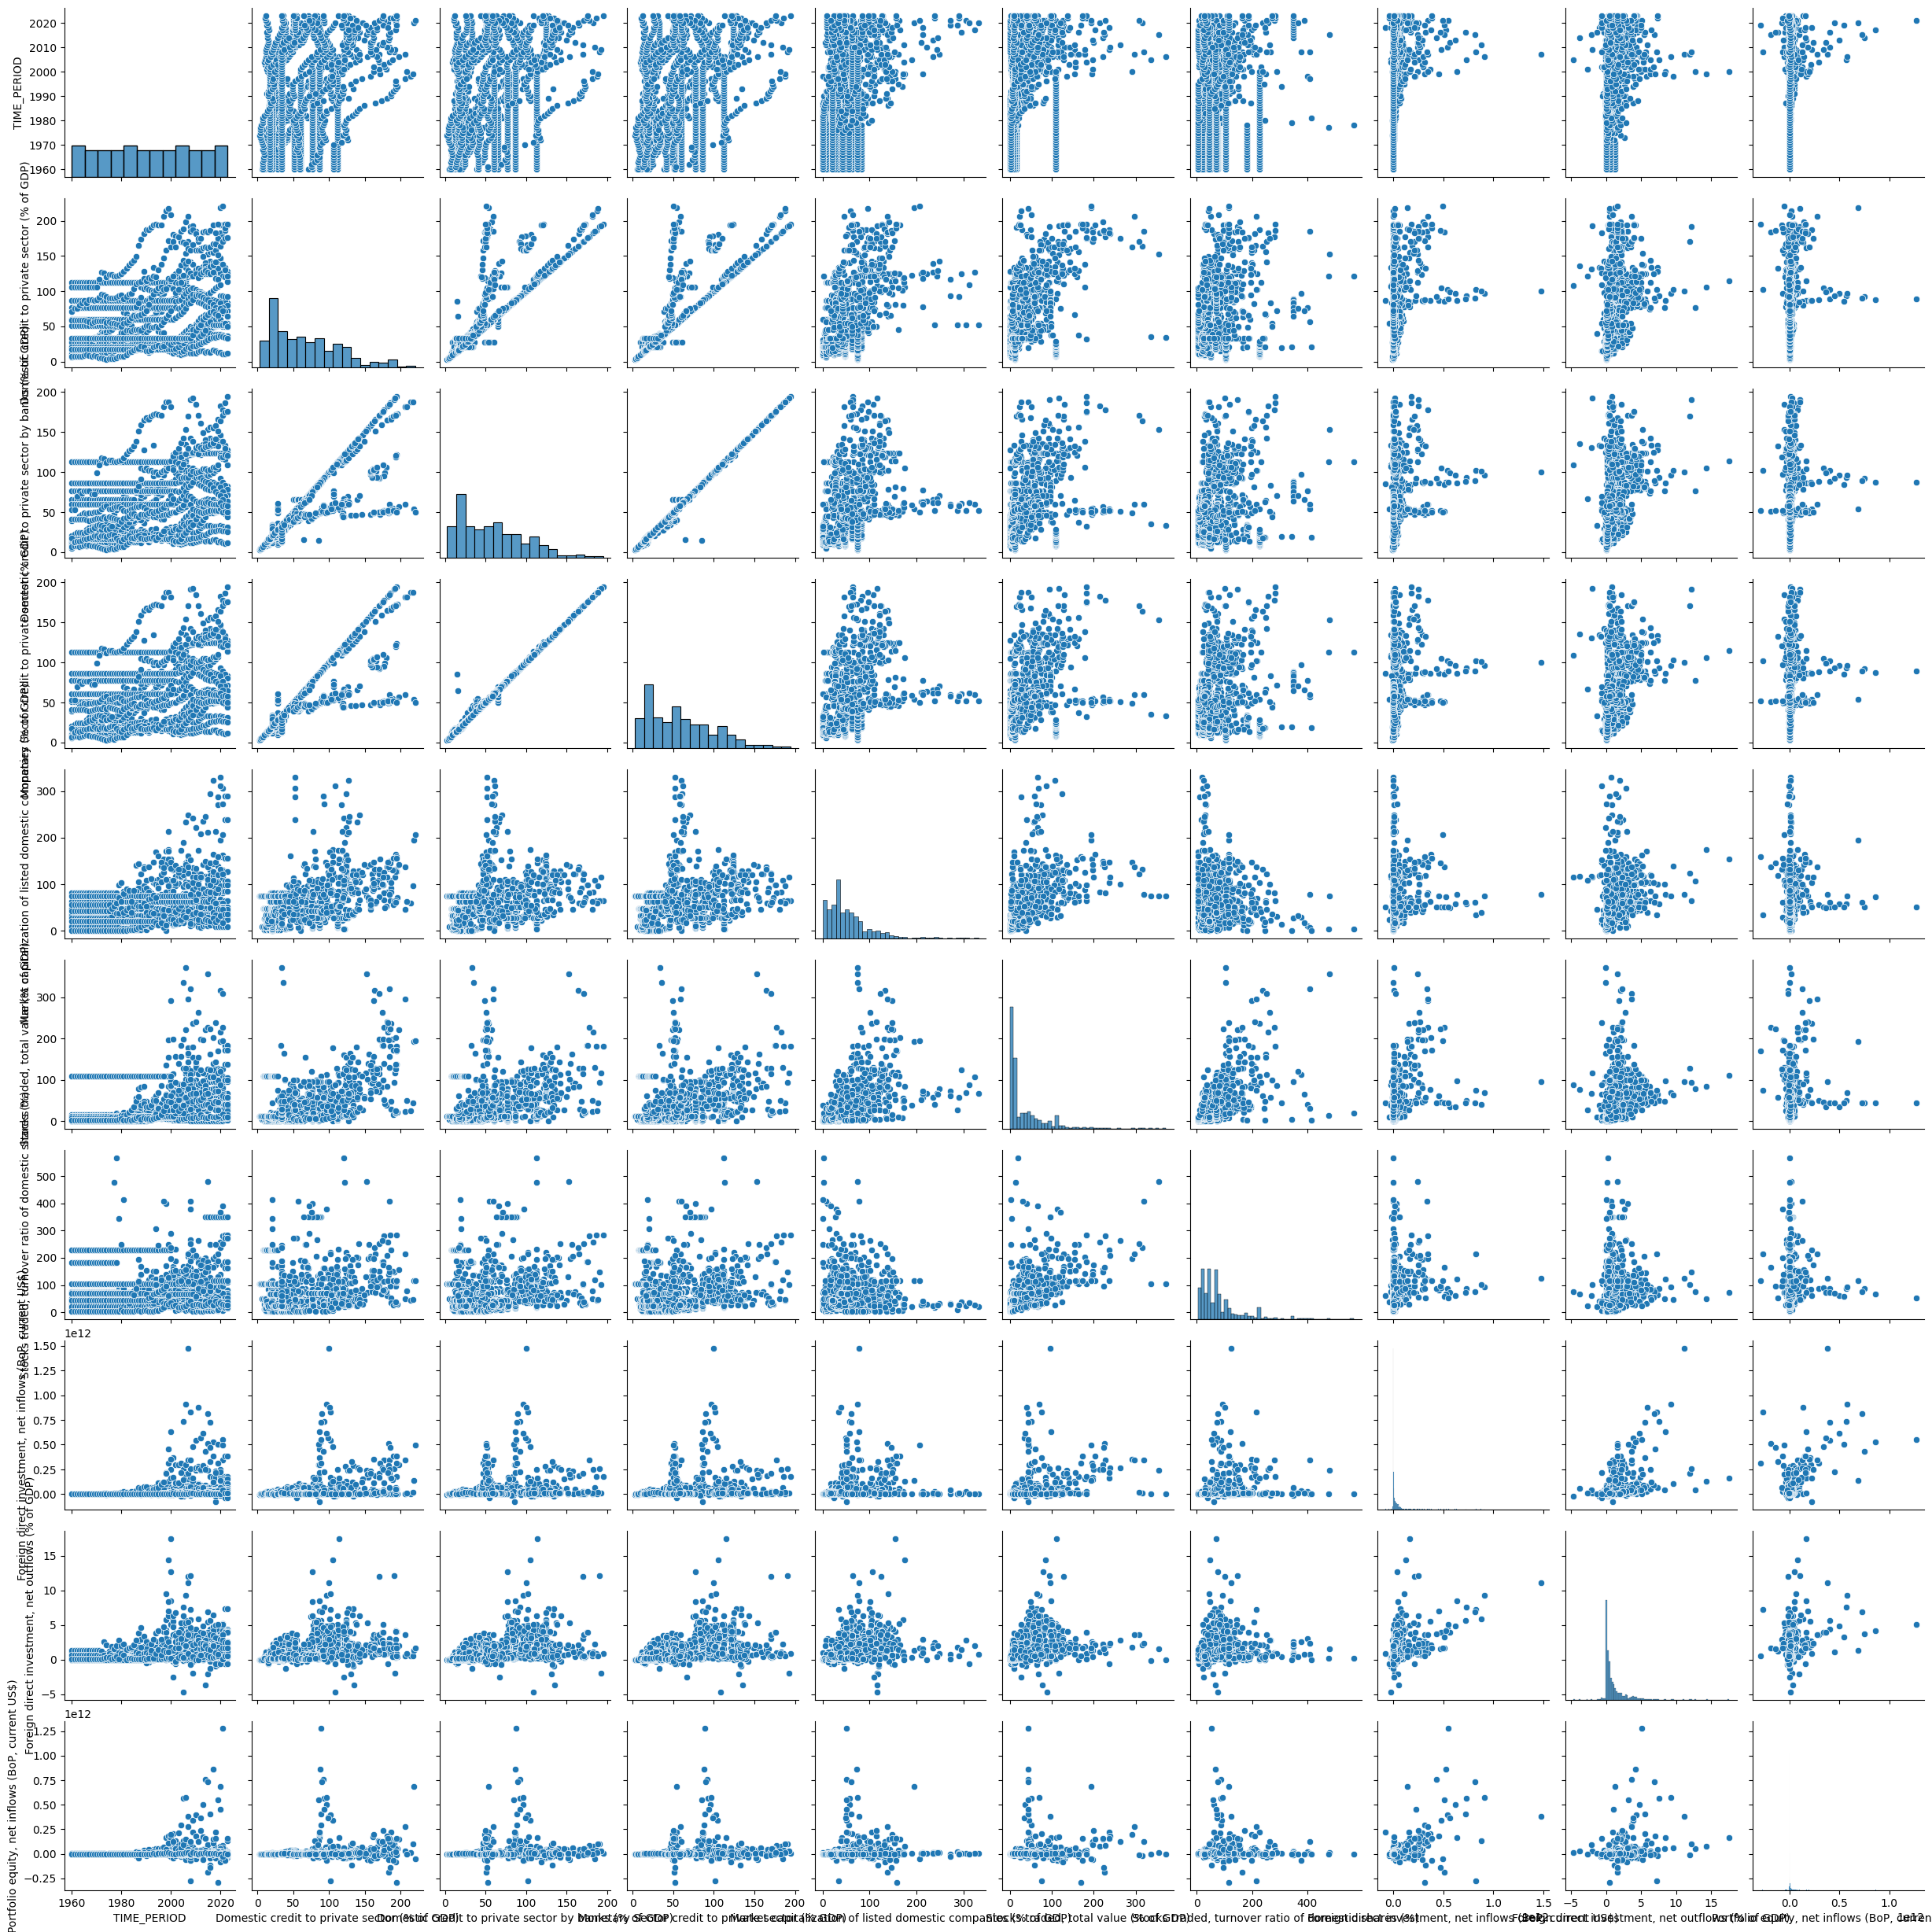

In [64]:
sns.pairplot(df)
plt.show()

***Indicator skewness for each country***

In [68]:
df.groupby(by='REF_AREA_LABEL').skew(numeric_only=True)

INDICATOR_LABEL,TIME_PERIOD,Domestic credit to private sector (% of GDP),Domestic credit to private sector by banks (% of GDP),Monetary Sector credit to private sector (% GDP),Market capitalization of listed domestic companies (% of GDP),"Stocks traded, total value (% of GDP)","Stocks traded, turnover ratio of domestic shares (%)","Foreign direct investment, net inflows (BoP, current US$)","Foreign direct investment, net outflows (% of GDP)","Portfolio equity, net inflows (BoP, current US$)"
REF_AREA_LABEL,,,,,,,,,,
Argentina,0,1.553351,1.548280,1.553351,0.799048,4.855709,4.483962,1.515004,1.052259,-2.994297
Australia,0,0.357761,0.353568,0.357761,0.508490,0.992338,0.522688,1.122319,1.498829,1.109038
Brazil,0,1.202027,1.308142,1.202027,2.644373,1.720344,2.686285,1.226794,2.055143,2.973366
Canada,0,0.012448,0.007664,0.012448,1.328784,0.552660,0.918481,1.649979,0.753129,-0.021319
China,0,0.737132,1.010946,0.737132,2.396615,2.073336,2.202526,1.210075,1.072639,2.125342
European Union,0,1.983907,1.929607,1.983907,0.520807,0.940104,1.237014,1.617576,1.438257,1.964587
France,0,1.825163,1.695937,1.825163,0.518054,0.787842,4.663984,1.306456,2.209730,1.806417
Germany,0,-1.244412,-1.245334,-1.244412,0.515234,1.152018,2.043108,2.059951,0.840483,0.830404
India,0,0.403416,0.403416,0.403416,1.904846,-0.940326,-0.732656,1.316033,2.288639,1.420748


***Cleaned dataset for feature engineering***

In [69]:
df.to_csv('final_data.csv', index=False)